In [1]:
import sys

print(sys.executable)

c:\Users\Jai Shree Shyam\Hotel-Demand-Analytics-and-Cancellation-Prediction-Project\venv\Scripts\python.exe


In [1]:
## LOAD THE DATASET 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
## READ THE DATASET

df = pd.read_csv("../data/raw/hotel_bookings.csv")

print(df.shape)

df.head()

(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


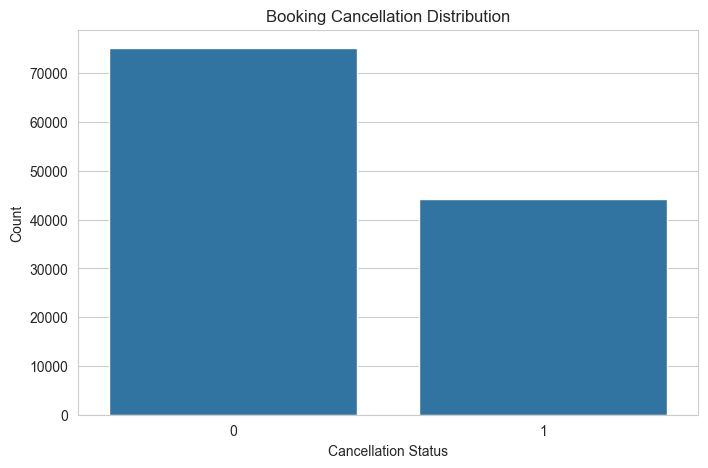

In [4]:
## CREATE CANCELLATION COUNT PLOT

plt.figure(figsize=(8,5))

sns.countplot(
    x = 'is_canceled', 
    data = df
)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Count")

plt.show()

In [5]:
## ANALYZE HOTEL TYPE vs CANCELLATION RATE

hotel_cancel = pd.crosstab(
    df["hotel"],
    df["is_canceled"],
    normalize="index"
) * 100

hotel_cancel

is_canceled,0,1
hotel,,
City Hotel,58.273037,41.726963
Resort Hotel,72.236645,27.763355


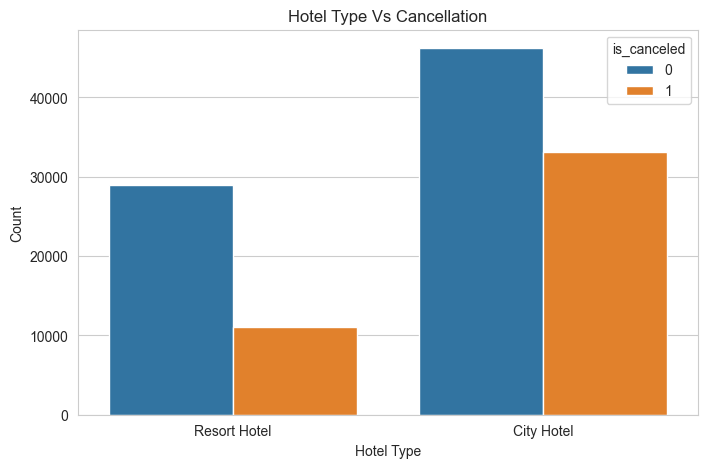

In [6]:
## VISULAIZATION OF THE DATA

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled"
)

plt.title("Hotel Type Vs Cancellation")
plt.xlabel("Hotel Type")
plt.ylabel("Count")

plt.show()

### Observation

- City Hotels have a significantly higher cancellation rate (41.73%) than Resort Hotels (27.76%).
- Resort Hotels show better booking retention.
- Hotel type appears to be a strong predictor of cancellation behavior.
- This variable should be retained for machine learning models.

In [7]:
# LEAD TIME vs CANCELLATION
## COMPARE AVERAGE LEAD TIME

df.groupby("is_canceled")["lead_time"].mean()


is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

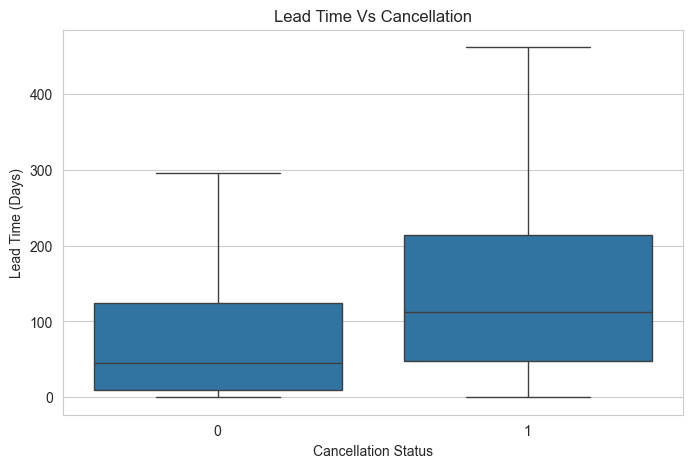

In [8]:
## VISULAIZATION OF THE DATA

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df, 
    x="is_canceled",
    y="lead_time",
    showfliers=False
)

plt.title("Lead Time Vs Cancellation")
plt.xlabel("Cancellation Status")
plt.ylabel("Lead Time (Days)")

plt.show()

### Observation

- Cancelled bookings generally have much higher lead times.
- Customers booking far in advance are more likely to cancel.
- Lead Time appears to be one of the strongest predictors of cancellation.
- This feature should definitely be retained during model building.

In [9]:
# MARKET SEGMENT vs CANCELLATION RATE
## VIEW MARKET SEGMENTS

df["market_segment"].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [10]:
## CALCULATE CANCELLATION RATE BY SEGMENT

segment_cancel = pd.crosstab(
    df["market_segment"],
    df["is_canceled"],
    normalize="index"
) * 100

segment_cancel

is_canceled,0,1
market_segment,,
Aviation,78.059072,21.940928
Complementary,86.944818,13.055182
Corporate,81.265345,18.734655
Direct,84.658099,15.341901
Groups,38.937964,61.062036
Offline TA/TO,65.683967,34.316033
Online TA,63.278857,36.721143
Undefined,0.000000,100.000000


In [11]:
## SORT BY CANCELLATION PERCENTAGE

segment_cancel.sort_values(
    by=1,
    ascending=False
)

is_canceled,0,1
market_segment,,
Undefined,0.000000,100.000000
Groups,38.937964,61.062036
Online TA,63.278857,36.721143
Offline TA/TO,65.683967,34.316033
Aviation,78.059072,21.940928
Corporate,81.265345,18.734655
Direct,84.658099,15.341901
Complementary,86.944818,13.055182


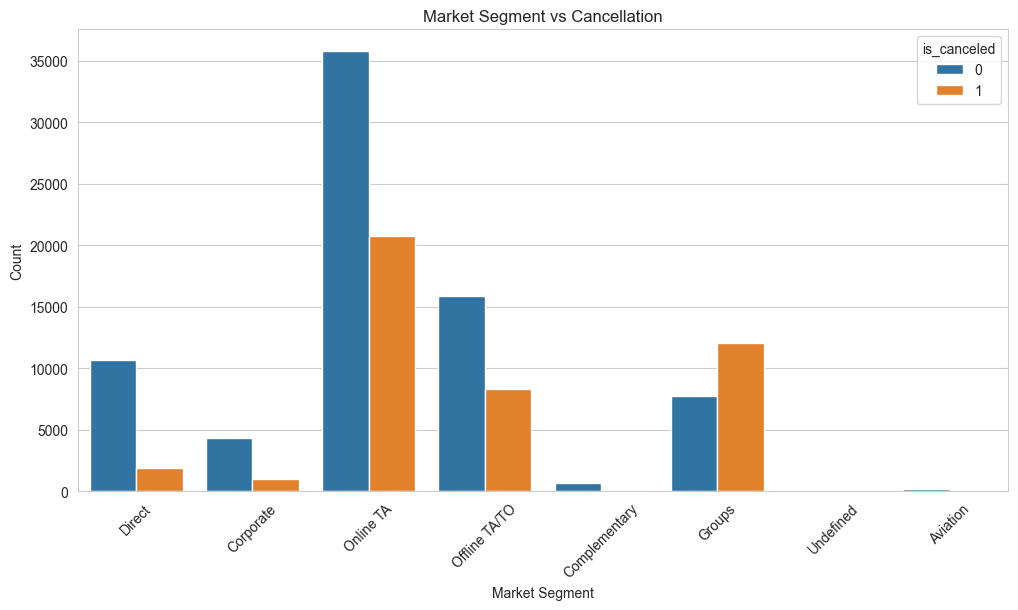

In [12]:
## VISUALIZATION OF THE DATA

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="market_segment",
    hue="is_canceled"
)

plt.title("Market Segment vs Cancellation")
plt.xlabel("Market Segment")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

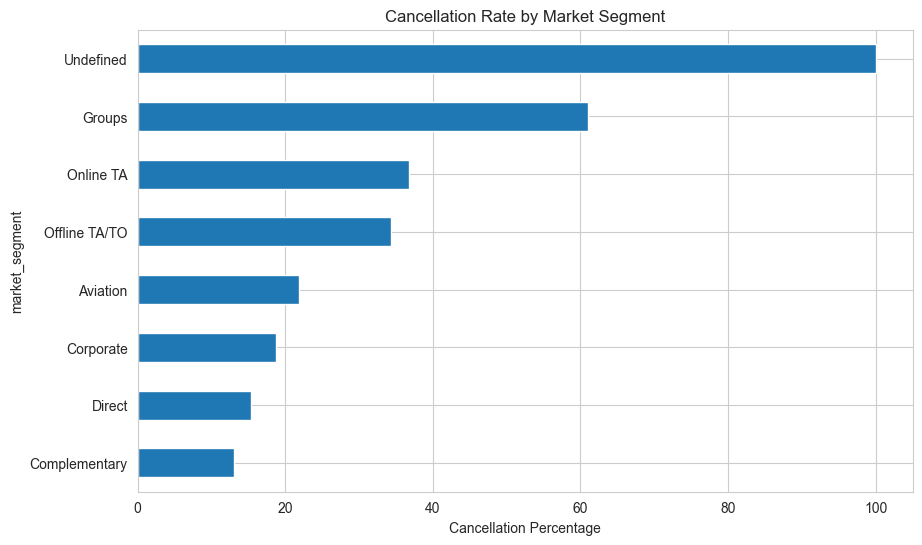

In [13]:
segment_cancel[1].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation Percentage")

plt.show()

### Observation

- Group bookings show the highest cancellation rate (61.06%).
- Online Travel Agencies have significantly higher cancellation rates than direct bookings.
- Direct and Corporate customers are relatively reliable.
- Market Segment is a strong predictor of cancellation behavior.
- Booking source should be retained for machine learning modeling.

In [14]:
# DEPOSIT TYPE vs CANCELLATION
## CHECK SAMPLE SIZE

df["deposit_type"].value_counts()

deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64

In [15]:
## CALCULATE CANCELLATION RATE BY DEPOSIT TYPE

deposit_cancel = pd.crosstab(
    df["deposit_type"],
    df["is_canceled"],
    normalize="index"
) * 100

deposit_cancel.sort_values(
    by=1,
    ascending=False
)

is_canceled,0,1
deposit_type,,
Non Refund,0.637554,99.362446
No Deposit,71.622978,28.377022
Refundable,77.777778,22.222222


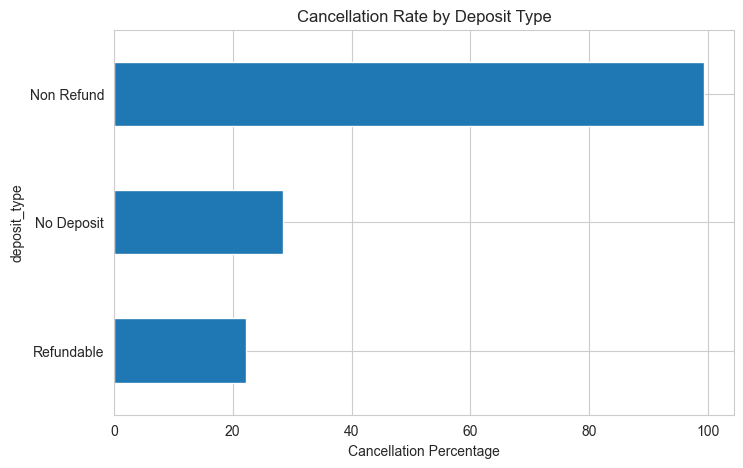

In [16]:
## VISUALIZATION OF THE DATA

deposit_cancel[1].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Cancellation Percentage")

plt.show()

### Observation

- Deposit Type has a strong relationship with cancellation behavior.
- Non Refund bookings show an extremely high cancellation rate (99.36%).
- No Deposit bookings have a cancellation rate of 28.38%.
- Refundable bookings have the lowest cancellation rate (22.22%).
- Deposit Type appears to be a highly predictive feature.

In [17]:
# CUSTOMER TYPE vs CANCELLATION
## VIEW CUSTOMER TYPE DISTRIBUTION

df["customer_type"].value_counts()

customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [18]:
## CALCULATE CANCELLATION RATE BY CUSTOMER TYPE

customer_cancel = pd.crosstab(
    df["customer_type"],
    df["is_canceled"],
    normalize="index"
) * 100

customer_cancel.sort_values(
    by=1,
    ascending=False
)

is_canceled,0,1
customer_type,,
Transient,59.253680,40.746320
Contract,69.038273,30.961727
Transient-Party,74.570132,25.429868
Group,89.774697,10.225303


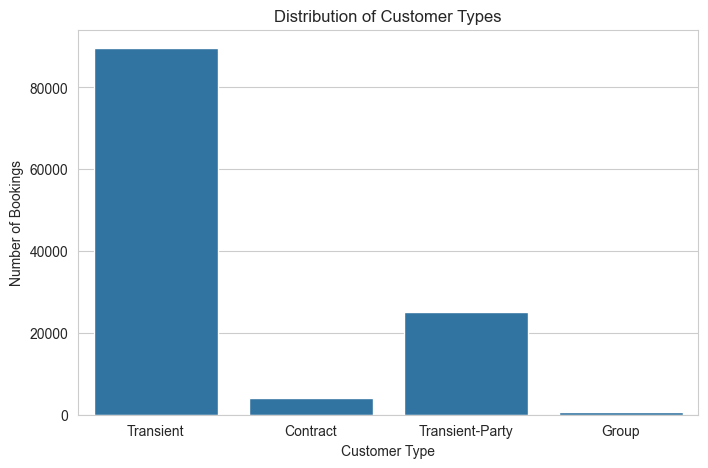

In [19]:
## VISUALIZATION CUSTOMER DISTRIBUTION

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="customer_type"
)

plt.title("Distribution of Customer Types")
plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")

plt.show()

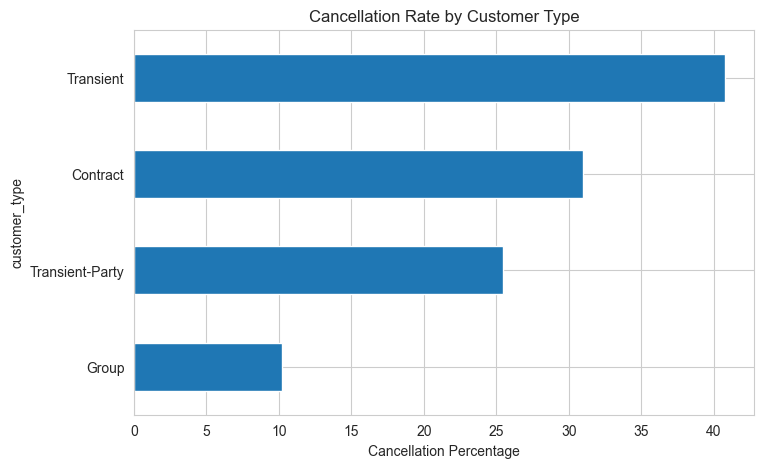

In [20]:
## VISUALIZATION CANCELLATION RATE

customer_cancel[1].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Cancellation Percentage")

plt.show()

### Final Observation

Customer Type has a noticeable impact on cancellation behavior.

- Transient customers exhibit the highest cancellation rate (40.75%).
- Contract customers show moderate cancellation behavior (30.96%).
- Transient-Party customers are comparatively more reliable (25.43%).
- Group customers have the lowest cancellation rate (10.23%).

These findings suggest that Customer Type contains valuable predictive information and should be retained during machine learning model development.

## DATA CLEANING AND FEATURE ENGINEERING

In [22]:
## CHECK THE MISSING VALUES

df.isnull().sum()


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [24]:
## HANDLE MISSING VALUES

df["children"] = df["children"].fillna(0)
df["agent"] = df["agent"].fillna(0)
df["country"] = df["country"].fillna("Unkown")
df["company"] = df["company"].fillna(0)

df.isnull().sum()


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

### Missing Value Handling

- children had only 4 missing values and was replaced with 0.
- country missing values were replaced with "Unknown".
- agent and company contained large numbers of missing values and were replaced with 0.
- Dataset is now ready for feature engineering.

In [26]:
## CONVERT DATE COLUMN

df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])
df["reservation_status_date"].dtype

dtype('<M8[us]')

In [ ]:
## CREATE TOTAL NIGHTS COLUMN

df["total_nights"] = df["stays_in_weekend_nights"] +  df["stays_in_week_nights"]
df[["stays_in_weekend_nights", "stays_in_week_nights", "total_nights"]].head()

,stays_in_weekend_nights,stays_in_week_nights,total_nights
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2
...,...,...,...
119385,2,5,7
119386,2,5,7
119387,2,5,7
119388,2,5,7


In [ ]:
## CREATE TOTAL GUESTS COLUMN

df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df[["adults", "children", "babies","total_guests"]].head()

,adults,children,babies,total_guests
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


In [39]:
## CREATE ARRIVAL MONTH(NUM) COLUMN

df["arrival_date_num"] = pd.to_datetime(
    df["arrival_date_month"],
    format="%B"
).dt.month

df[["arrival_date_month", "arrival_date_num"]].head()

,arrival_date_month,arrival_date_num
0,July,7
1,July,7
2,July,7
3,July,7
4,July,7


In [40]:
## CREATE STAY TYPE COLUMN

df["stay_type"] = np.where(
    df["total_nights"] <=3,
    "Short Stay",
    np.where(df["total_nights"] <=7, "Medium Stay", "Long Stay")
)

df["stay_type"].value_counts()

stay_type
Short Stay     76454
Medium Stay    37679
Long Stay       5257
Name: count, dtype: int64

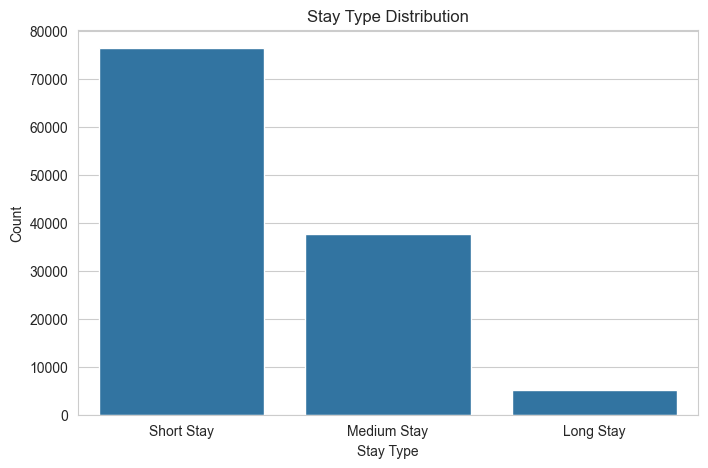

In [41]:
## VISUALIZE STAY TYPE

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="stay_type",
    order=df["stay_type"].value_counts().index
)

plt.title("Stay Type Distribution")
plt.xlabel("Stay Type")
plt.ylabel("Count")

plt.show()

In [42]:
## SAVE CLEANED DATASET

df.to_csv("../data/processed/hotel_bookings_cleaned.csv", index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [43]:
## VERIFY SAVED FILE

import os

os.path.exists("../data/processed/hotel_bookings_cleaned.csv")

True

# Day 3 Summary

Completed Tasks:

- Missing value handling
- Date parsing
- Feature engineering
- Created total_nights
- Created total_guests
- Created arrival_month_num
- Created stay_type
- Saved cleaned dataset

Key Findings:

- City Hotels have higher cancellation rates.
- Long lead times increase cancellation probability.
- Online Travel Agencies contribute significantly to cancellations.
- Deposit type strongly influences cancellation behaviour.
- Customer type impacts booking reliability.

The dataset is now cleaned and prepared for SQL analytics and dashboard development.

In [ ]:
## MONTHLY BOOKING TREND